In [1]:
#load packages
import numpy as np
import xarray as xr
import math
import csv

import matplotlib.pyplot as plt
%matplotlib inline

import os
import pandas as pd
import cmocean
import matplotlib.gridspec as gridspec

from scipy.stats import norm
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, zoomed_inset_axes

# import gsw_xarray as gsw_xr # seawater calculations - might not need this one
import gsw as gsw
## mapping packages
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pyproj import Transformer, Geod
from shapely.geometry import LineString, Point
from scipy.signal import savgol_filter
from scipy.interpolate import griddata

In [2]:
cd /g/data/jk72/deg581/seqom/analysis/notebooks

/g/data/jk72/deg581/seqom/analysis/notebooks


In [3]:
#define functions
def inpolygon(xq, yq, xv, yv):
    from matplotlib import path
    shape = xq.shape
    xq = xq.reshape(-1)
    yq = yq.reshape(-1)
    xv = xv.reshape(-1)
    yv = yv.reshape(-1)
    q = [(xq[i], yq[i]) for i in range(xq.shape[0])]
    p = path.Path([(xv[i], yv[i]) for i in range(xv.shape[0])])
    return p.contains_points(q).reshape(shape)

from xgcm import Grid

# map u,v to rho points
def ROMSmetricsAndGrid(ds):
    ds = ds.rename({'eta_u': 'eta_rho', 'xi_v': 'xi_rho', 'xi_psi': 'xi_u', 'eta_psi': 'eta_v'})

    coords={'X':{'center':'xi_rho', 'inner':'xi_u'}, 
        'Y':{'center':'eta_rho', 'inner':'eta_v'}, 
        'Z':{'center':'s_rho', 'outer':'s_w'}}

    grid = Grid(ds, coords=coords, periodic=[])

    print('making pm/pn metrics')
    ds['pm_v'] = grid.interp(ds.pm, 'Y')
    ds['pn_u'] = grid.interp(ds.pn, 'X')
    ds['pm_u'] = grid.interp(ds.pm, 'X')
    ds['pn_v'] = grid.interp(ds.pn, 'Y')
    ds['pm_psi'] = grid.interp(grid.interp(ds.pm, 'Y'),  'X') # at psi points (eta_v, xi_u) 
    ds['pn_psi'] = grid.interp(grid.interp(ds.pn, 'X'),  'Y') # at psi points (eta_v, xi_u)
    print('making dx/dy')
    ds['dx'] = 1/ds.pm
    ds['dx_u'] = 1/ds.pm_u
    ds['dx_v'] = 1/ds.pm_v
    ds['dx_psi'] = 1/ds.pm_psi

    ds['dy'] = 1/ds.pn
    ds['dy_u'] = 1/ds.pn_u
    ds['dy_v'] = 1/ds.pn_v
    ds['dy_psi'] = 1/ds.pn_psi

#     ds['dz'] = grid.diff(ds.z_w, 'Z', boundary='fill')
#     ds['dz_w'] = grid.diff(ds.z_rho, 'Z', boundary='fill')
#     ds['dz_u'] = grid.interp(ds.dz, 'X')
#     ds['dz_w_u'] = grid.interp(ds.dz_w, 'X')
#     ds['dz_v'] = grid.interp(ds.dz, 'Y')
#     ds['dz_w_v'] = grid.interp(ds.dz_w, 'Y')

    ds['dA'] = ds.dx * ds.dy

    metrics = {
        ('X',): ['dx', 'dx_u', 'dx_v', 'dx_psi'], # X distances
        ('Y',): ['dy', 'dy_u', 'dy_v', 'dy_psi'], # Y distances
        # ('Z',): ['dz', 'dz_u', 'dz_v', 'dz_w', 'dz_w_u', 'dz_w_v'], # Z distances
        ('X', 'Y'): ['dA'] # Areas
    }
    grid = Grid(ds, coords=coords, metrics=metrics, periodic=[])

    return ds,grid



def add_zeros_to_4(date):
    if date<10:
        to_add = '000'
    elif date>9 & date<100:
        to_add = '00'
    elif date>99 & date < 1000:
        to_add = '0'
    else: 
        to_add = ''
    return to_add

def generateFileList(FilePath,prefix,datelist):
    filelist=[FilePath+prefix+add_zeros_to_4(datelist[0])+str(datelist[0])+'.nc']
    for dates in datelist[1:]:
        filenameToAppend=FilePath+prefix+add_zeros_to_4(dates)+str(dates)+'.nc'
        filelist.append(filenameToAppend)
    return filelist

# Load Data

# Now get the model data

In [4]:
# load data file

grd = xr.open_dataset('/g/data/jk72/deg581/se-qld-setup/data/proc/seqld_1km_v1.7_grd.nc')

FilePath='/g/data/jk72/deg581/seqom/seqom_v1.7_2012_continue2/' #

prefix='roms_his_'
timeRange = [17,18]
datelist = np.array(range(timeRange[0],timeRange[1],1))


fl=generateFileList(FilePath,prefix,datelist)
print(fl)

# ds=loadOverlappedNetcdfFileList(filelist=fl,overlapDays=7)

ds = xr.open_mfdataset(fl,chunks = {'ocean_time':1}, data_vars='minimal', compat='override',coords='minimal',parallel='False',join='right')

print(ds.nbytes/1e9,'G')

ds = ds.drop_vars(['u','v','ubar_eastward','vbar_northward','w','rho','shflux','ssflux','sustr','svstr'])
print(ds.nbytes/1e9,'G')
ds

ds = ds.assign_coords({"lon_rho": grd.lon_rho})
ds = ds.assign_coords({"lat_rho": grd.lat_rho})

weights_area = (1/ds.pm)*(1/ds.pn)
weights_area.name = "weights"

print('making vertical coordinates')
Zo_rho = (ds.hc * ds.s_rho + ds.Cs_r * ds.h) / (ds.hc + ds.h)
z_rho =  ( ds.h) * Zo_rho
Zo_w = (ds.hc * ds.s_w + ds.Cs_w * ds.h) / (ds.hc + ds.h)
z_w = Zo_w * ( + ds.h) 
    
ds.coords['z_w0'] = z_w.where(ds.mask_rho, 0).transpose('s_w', 'eta_rho', 'xi_rho')
ds.coords['z_rho0'] = z_rho.where(ds.mask_rho, 0).transpose('s_rho', 'eta_rho', 'xi_rho')

ds['dz'] = (('s_rho', 'eta_rho', 'xi_rho'),np.diff(ds.z_w0,axis=0))


ds, grid = ROMSmetricsAndGrid(ds)

# ds_17_again = ds

# ds.close()

['/g/data/jk72/deg581/seqom/seqom_v1.7_2012_continue2/roms_his_0017.nc']
39.617066672 G
19.387703792 G
making vertical coordinates
making pm/pn metrics
making dx/dy


In [5]:
ds.load()


<xarray.Dataset>
Dimensions:         (tracer: 2, boundary: 4, s_rho: 31, s_w: 32, Nuser: 1,
                     eta_rho: 720, xi_rho: 735, xi_u: 734, eta_v: 719,
                     ocean_time: 73)
Coordinates: (12/15)
  * s_rho           (s_rho) float64 -0.9839 -0.9516 ... -0.04839 -0.01613
  * s_w             (s_w) float64 -1.0 -0.9677 -0.9355 ... -0.06452 -0.03226 0.0
    x_rho           (eta_rho, xi_rho) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    y_rho           (eta_rho, xi_rho) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    x_u             (eta_rho, xi_u) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    y_u             (eta_rho, xi_u) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    ...              ...
    y_psi           (eta_v, xi_u) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
  * ocean_time      (ocean_time) datetime64[ns] 2016-01-02 ... 2016-12-27
    lon_rho         (eta_rho, xi_rho) float64 151.5 151.5 151.5 ... 158.8 158.8
    lat_rho         (eta_rho, xi_rho) float64 -31.2 -31.2 ... -24.01 -24.01
    z_w0            (s_w, eta_rho, xi_rho) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    z_rho0          (s_rho, eta_rho, xi_rho) float64 0.0 0.0 ... -1.115 -1.116
Dimensions without coordinates: tracer, boundary, Nuser, eta_rho, xi_rho, xi_u,
                                eta_v
Data variables: (12/109)
    ntimes          int32 1051200
    ndtfast         int32 20
    dt              float64 30.0
    dtfast          float64 1.5
    dstart          datetime64[ns] 2000-01-01
    nHIS            int32 14400
    ...              ...
    dx_psi          (eta_v, xi_u) float64 951.2 951.2 ... 1.016e+03 1.016e+03
    dy              (eta_rho, xi_rho) float64 1.112e+03 1.112e+03 ... 1.112e+03
    dy_u            (eta_rho, xi_u) float64 1.112e+03 1.112e+03 ... 1.112e+03
    dy_v            (eta_v, xi_rho) float64 1.112e+03 1.112e+03 ... 1.112e+03
    dy_psi          (eta_v, xi_u) float64 1.112e+03 1.112e+03 ... 1.112e+03
    dA              (eta_rho, xi_rho) float64 1.058e+06 1.058e+06 ... 1.129e+06
Attributes: (12/35)
    file:              roms_his_0017.nc
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS/TOMS history file
    title:             South-east Queensland, 1/100 (900m) degree resolution
    var_info:          ROMS/External/varinfo.yaml
    ...                ...
    compiler_command:  /apps/openmpi/4.0.2/bin/mpif90
    compiler_flags:    -fp-model precise -heap-arrays -ip -O3 -traceback -che...
    tiling:            024x020
    history:           ROMS/TOMS, Version 4.2, Saturday - January 10, 2026 - ...
    ana_file:          ROMS/Functionals/ana_btflux.h
    CPP_options:       SEQLD, ANA_BSFLUX, ANA_BTFLUX, ASSUMED_SHAPE, AVERAGES...

In [6]:
times = ds.ocean_time.values- np.timedelta64(4*365+1, 'D') # correct for model date offset.


# make masks for model

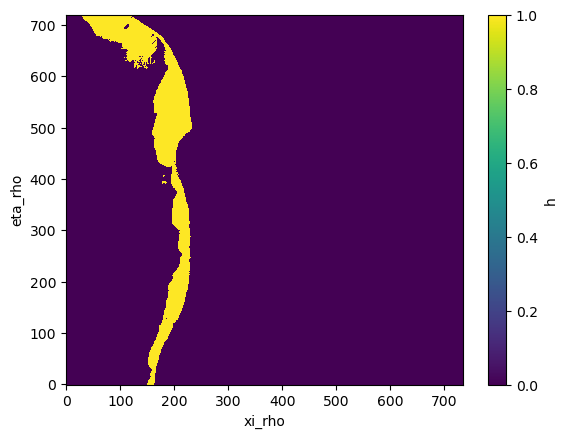

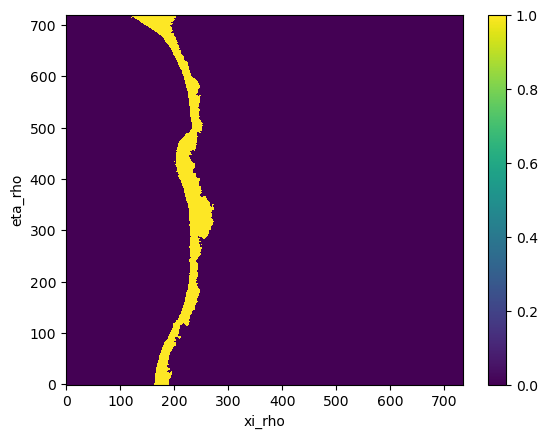

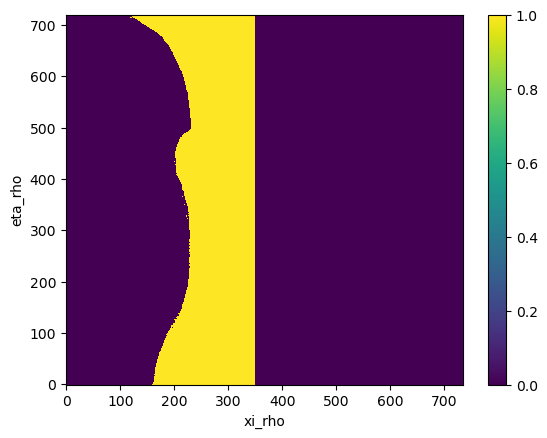

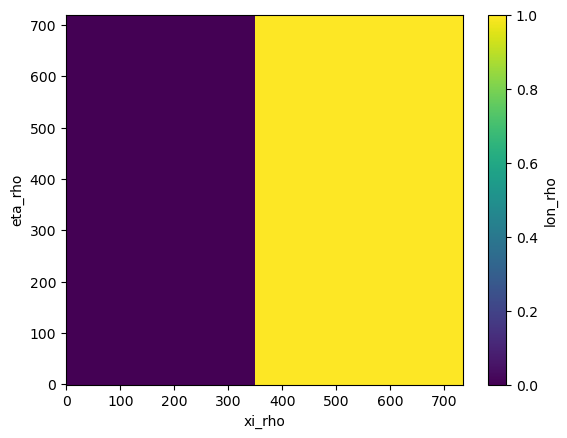

In [7]:
weights = ds.dA
weights.name = "weights"


# Shelf
mask_shelf = (ds.h<100) & (ds.h>20)

mask_shelf.plot()
plt.show()

#ds.temp.isel(s_rho=-1).where(mask_shelf).mean(dim='eta_rho').mean(dim='xi_rho').plot()
#ds.temp.isel(s_rho=-1).where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')).plot()


# Slope
mask_slope = (ds.h>100) & (ds.h<1500) & (ds.lon_rho<154.3)

mask_slope.plot()
plt.show()

# EAC
mask_eac = (ds.h>90) & (ds.lon_rho<155)

mask_eac.plot()
plt.show()

# offshore
mask_offshore = (ds.lon_rho>155)

mask_offshore.plot()
plt.show()

# calculate rectified currents

 time-mean rectified

In [8]:

# Time mean velocities
u_mean = ds.u_eastward.mean(dim='ocean_time').isel(s_rho=-1)
v_mean = ds.v_northward.mean(dim='ocean_time').isel(s_rho=-1)

# Rectified velocities (time mean of squares minus squares of means)
u_rect_tav = (ds.u_eastward**2).isel(s_rho=-1).mean(dim='ocean_time') - u_mean**2
v_rect_tav = (ds.v_northward**2).isel(s_rho=-1).mean(dim='ocean_time') - v_mean**2

u_rect_tav

<xarray.DataArray 'u_eastward' (eta_rho: 720, xi_rho: 735)>
array([[       nan,        nan,        nan, ..., 0.        , 0.        ,
        0.        ],
       [       nan,        nan,        nan, ..., 0.11171127, 0.09244397,
        0.        ],
       [       nan,        nan,        nan, ..., 0.09815299, 0.09034216,
        0.        ],
       ...,
       [       nan,        nan,        nan, ..., 0.02978192, 0.02548447,
        0.        ],
       [       nan,        nan,        nan, ..., 0.04009461, 0.02586806,
        0.        ],
       [       nan,        nan,        nan, ..., 0.        , 0.        ,
        0.        ]], dtype=float32)
Coordinates:
    s_rho    float64 -0.01613
    x_rho    (eta_rho, xi_rho) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    y_rho    (eta_rho, xi_rho) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    lon_rho  (eta_rho, xi_rho) float64 151.5 151.5 151.5 ... 158.8 158.8 158.8
    lat_rho  (eta_rho, xi_rho) float64 -31.2 -31.2 -31.2 ... -24.01 -24.01
    z_rho0   (eta_rho, xi_rho) float64 0.0 0.0 0.0 0.0 ... -1.113 -1.115 -1.116
Dimensions without coordinates: eta_rho, xi_rho

time-filtered rectified

In [9]:
# from scipy.signal import butter, filtfilt

# def bandpass_3d(data, dt, cutoff_low, cutoff_high):
#     """
#     Bandpass filter along the first axis (time) for 3D arrays (time, y, x)
#     """
#     nyq = 0.5 / dt
#     b, a = butter(N=4, Wn=[cutoff_low/nyq, cutoff_high/nyq], btype='band')
#     # output array
#     filtered = np.empty_like(data)
#     # loop over y,x
#     for j in range(data.shape[1]):
#         for i in range(data.shape[2]):
#             filtered[:, j, i] = filtfilt(b, a, data[:, j, i])
#     return filtered

# # Suppose dt in days, cutoff_high = 1 days, cutoff_low = 10 day
# u_highfreq = bandpass_3d(ds.u_eastward.isel(s_rho=-1).values, dt=5, cutoff_low=1/10, cutoff_high=1/1)
# v_highfreq = bandpass_3d(ds.v_northward.isel(s_rho=-1).values, dt=5, cutoff_low=1/10, cutoff_high=1/1)

# # Time-mean of high-frequency component
# u_rect_tfilt = u_highfreq.mean(axis=0)
# v_rect_tfilt = v_highfreq.mean(axis=0)

Spatial-filtered rectified

In [10]:
from scipy.ndimage import gaussian_filter

# Gaussian smoothing (sigma in grid points, adjust for ~30 km)
u_smooth = gaussian_filter(ds.u_eastward.isel(s_rho=-1).mean(dim='ocean_time'), sigma=5)
v_smooth = gaussian_filter(ds.v_northward.isel(s_rho=-1).mean(dim='ocean_time'), sigma=5)

# Submesoscale residual
u_rect_spfilt = ds.u_eastward.isel(s_rho=-1).mean(dim='ocean_time') - u_smooth
v_rect_spfilt = ds.v_northward.isel(s_rho=-1).mean(dim='ocean_time') - v_smooth

In [33]:
from scipy.ndimage import gaussian_filter
def gaussian_nan(da, sigma):
    
    # Ocean mask: 1 where valid, 0 where NaN
    mask = xr.where(np.isfinite(da), 1.0, 0.0)
    
    # Replace NaNs with 0
    da_filled = da.fillna(0)
    
    # Apply Gaussian filter to data and mask
    data_smooth = xr.apply_ufunc(
        gaussian_filter,
        da_filled,
        input_core_dims=[['eta_rho','xi_rho']],
        output_core_dims=[['eta_rho','xi_rho']],
        kwargs={'sigma': sigma},
        vectorize=True
    )
    
    weight_smooth = xr.apply_ufunc(
        gaussian_filter,
        mask,
        input_core_dims=[['eta_rho','xi_rho']],
        output_core_dims=[['eta_rho','xi_rho']],
        kwargs={'sigma': sigma},
        vectorize=True
    )
    
    # Renormalise
    result = data_smooth / weight_smooth
    
    # Restore NaNs on land
    result = result.where(mask > 0)
    
    return result


# --- Parameters ---
sigma_km = 10000   # Gaussian filter scale in m
dx = (1/ds.pm).mean(dim={'xi_rho','eta_rho'}).values        # grid spacing in km (adjust to your ROMS grid)
sigma = sigma_km / dx  # convert km to grid points

# u = ds.u_eastward.isel(s_rho=-1).fillna(0)
# v = ds.v_northward.isel(s_rho=-1).fillna(0)

# # --- Step 1: Apply spatial Gaussian filter to time-mean → mesoscale (smoothed) ---
# u_smooth = xr.apply_ufunc(gaussian_filter, u,input_core_dims=[['eta_rho','xi_rho']],output_core_dims=[['eta_rho','xi_rho']],kwargs={'sigma': sigma},vectorize=True)
# v_smooth = xr.apply_ufunc(gaussian_filter, v,input_core_dims=[['eta_rho','xi_rho']],output_core_dims=[['eta_rho','xi_rho']],kwargs={'sigma': sigma},vectorize=True)

u = ds.u_eastward.isel(s_rho=-1)
v = ds.v_northward.isel(s_rho=-1)

u_smooth = gaussian_nan(u, sigma)
v_smooth = gaussian_nan(v, sigma)

# --- Step 2: Submesoscale residuals (time-mean minus smoothed) ---
u_submeso_inst = u - u_smooth
v_submeso_inst = v - v_smooth


# --- Step 3: Time-mean of submesoscale residuals → rectified flow ---
u_rect_spfilt2 = u_submeso_inst.mean(dim='ocean_time')
v_rect_spfilt2 = v_submeso_inst.mean(dim='ocean_time')

# --- Step 4: Magnitude of rectified flow ---
rect_mag_spfilt2 = np.sqrt(u_rect_spfilt2**2 + v_rect_spfilt2**2)

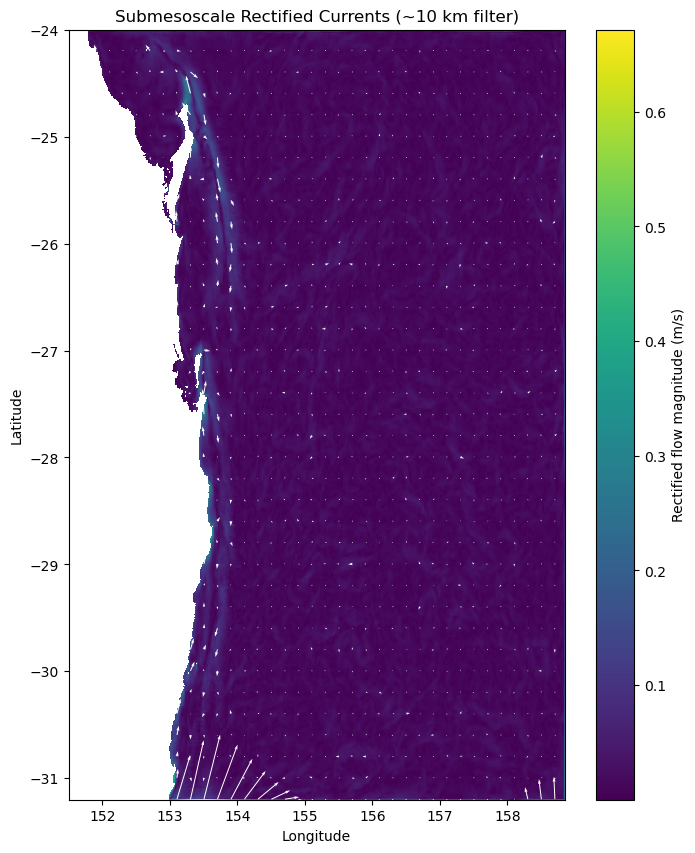

In [36]:
# --- Plot ---
plt.figure(figsize=(8,10))

col = plt.pcolormesh(ds.lon_rho, ds.lat_rho, rect_mag_spfilt2*ds.mask_rho, shading='auto', cmap='viridis')
plt.colorbar(col, label='Rectified flow magnitude (m/s)')

res = 20  # plot every 5th grid point
lon_q = ds.lon_rho.values[::res,::res]
lat_q = ds.lat_rho.values[::res,::res]
u_q = (u_rect_spfilt2*ds.mask_rho)[::res, ::res]
v_q = (v_rect_spfilt2*ds.mask_rho)[::res, ::res]
plt.quiver(lon_q, lat_q, u_q, v_q, scale=5, width=0.002, color='white')

plt.title('Submesoscale Rectified Currents (~10 km filter)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

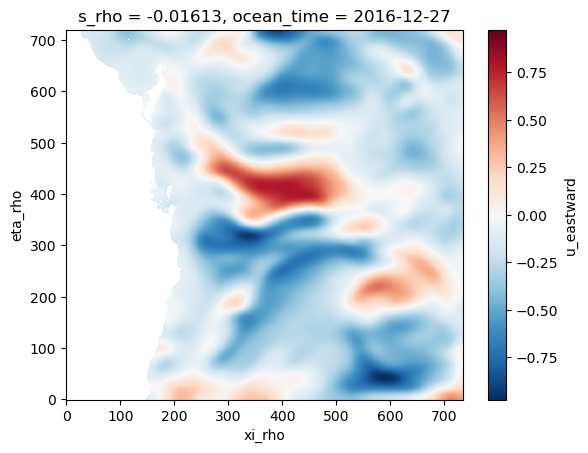

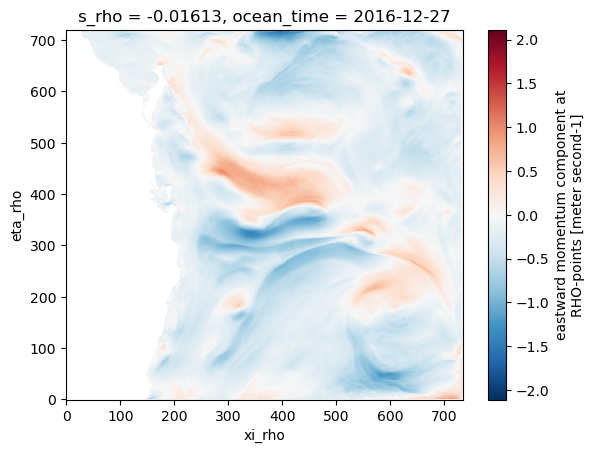

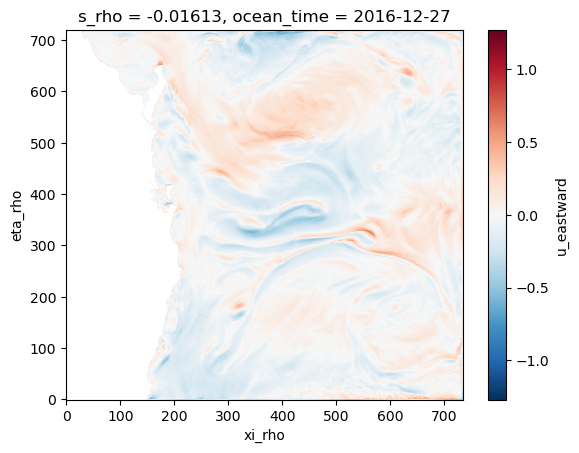

In [32]:
u_smooth.isel(ocean_time=-1).plot()
plt.show()
u.isel(ocean_time=-1).plot()
plt.show()
(u-u_smooth).isel(ocean_time=-1).plot()


In [13]:
STOP

NameError: name 'STOP' is not defined

In [ ]:
import matplotlib.pyplot as plt

res = 5

plt.figure(figsize=(12,10))
plt.quiver(ds.lon_rho.values[0::res,0::res],ds.lat_rho.values[0::res,0::res], u_rect_tav.values[0::res,0::res], v_rect_tav.values[0::res,0::res], scale=55, width=0.001)
plt.title('Rectified Currents (Residual Impact of Submesoscales)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


plt.figure(figsize=(12,10))
plt.quiver(ds.lon_rho.values[0::res,0::res],ds.lat_rho.values[0::res,0::res], u_rect_spfilt.values[0::res,0::res], v_rect_spfilt.values[0::res,0::res], scale=5, width=0.001)
plt.title('Rectified Currents (Residual Impact of Submesoscales)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()